# Notebook 1: Data Loading, Label Harmonisation & EDA

**Dataset:** Tisch24 Merged scRNA-seq — Human Kidney Cells (80–85% Variance Retained)  
**Task:** Multiclass classification — predict kidney cell type from gene expression  
**Input:** `Tisch24_MergedscRNA_80-85PctVAR.csv`  
**Output:** `kidney_cells_clean.csv`, `kidney_cells_top_classes.csv`

---

## What this notebook does
1. Mount Google Drive and load the raw dataset
2. Inspect the dataset
3. Harmonise cell type labels across studies
4. Remove rare cell types
5. EDA — class distribution, missing values, prominent classes, gene detection, sparsity
6. Save the cleaned dataset

## 1. Setup

The notebook reads and writes CSV files in the folder set as `data_dir` in the next cell. For a local run this is the repository folder (which contains the dataset). On Google Colab, mount your Drive and point `data_dir` at the folder holding the data.

In [1]:
# Data files live in the folder set as `data_dir` in the next cell.
# For a local run this is the repo folder (the default). On Google Colab instead,
# uncomment the two lines below to mount your Drive and point data_dir at it.
# from google.colab import drive
# drive.mount('/content/drive')
print('Setup: reading/writing files from the folder set as data_dir below.')

Setup: reading/writing files from the folder set as data_dir below.


## 2. Configuration

Set `data_dir` to the folder that holds the dataset. Locally this is the repo folder (`.`); on Colab set it to your Drive folder. Everything else below defines the metadata columns and the thresholds used later.

Here we import all the Python libraries we need and set up the key variables. The only line you need to change is  — update it to match the folder on your Google Drive where the dataset is stored.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Folder holding the dataset CSV. Locally this is the repo folder ('.').
# On Colab, set this to your Drive folder, e.g. Path('/content/drive/MyDrive/...').
data_dir = Path('.')

raw_file   = data_dir / 'Tisch24_MergedscRNA_80-85PctVAR.csv'
clean_file = data_dir / 'kidney_cells_clean.csv'

# The 9 columns that describe the cell / patient - not gene expression
metadata_cols  = ['Cell_ID', 'nCount_RNA', 'nFeature_RNA',
                  'StudyOrigin_Author', 'percent.mt',
                  'Sex', 'Sampling_Location', 'Age', 'Cell_Labels']

target_col     = 'Cell_Labels'   # the column we want to predict
min_class_size = 100             # drop any cell type with fewer cells than this
top_n_classes  = 10              # how many prominent classes to highlight

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## 3. Load Raw Dataset

This reads the CSV file into a pandas DataFrame. The file is 292 MB so it may take a minute. We then print a quick summary of how many rows (cells) and columns there are.

In [3]:
print('Loading dataset...')
df = pd.read_csv(raw_file, low_memory=False)
print('Done.')
print()
print(f'Rows         : {df.shape[0]:,}')
print(f'Columns      : {df.shape[1]:,}')
print(f'Gene columns : {df.shape[1] - len(metadata_cols):,}')
print()
df.head(3)

Loading dataset...


Done.

Rows         : 60,725
Columns      : 2,367
Gene columns : 2,358



,Cell_ID,nCount_RNA,nFeature_RNA,StudyOrigin_Author,percent.mt,Sex,Sampling_Location,Age,Cell_Labels,A3GALT2,...,AC004024.1,AC002378.1,AC006378.1,AC005303.1,AL451042.1,LINC01967,AC016573.1,BX571846.1,AC019118.2,AC007785.3
0,NK1_GGGAACGCGCCA,1410.0,1014,Lake,0.0,Male,Cortex,NaN,Glomerular Epithelium and Podocytes,0,...,0,0,0,0,0,0,0,0,0,0
1,NK5_GGTCGTTCCCCC,885.0,643,Lake,0.0,Male,Cortex,NaN,Glomerular Epithelium and Podocytes,0,...,0,0,0,0,0,0,0,0,0,0
2,NK5_CTAAGATGCTGC,614.0,496,Lake,0.0,Male,Cortex,NaN,Glomerular Epithelium and Podocytes,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Initial Inspection

Here we look at the data types of each metadata column, check which columns have missing values, and count how many unique values each column contains. This gives us a first sense of what the data looks like before we do anything with it.

In [4]:
print('Data types:')
print(df[metadata_cols].dtypes)
print()

missing     = df[metadata_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print('Missing values (metadata columns):')
print(pd.DataFrame({'Count': missing, '%': missing_pct})[missing > 0])
print()

print('Unique values per column:')
for col in metadata_cols:
    print(f'  {col:<30}: {df[col].nunique(dropna=False)}')

Data types:
Cell_ID                object
nCount_RNA            float64
nFeature_RNA            int64
StudyOrigin_Author     object
percent.mt            float64
Sex                    object
Sampling_Location      object
Age                    object
Cell_Labels            object
dtype: object

Missing values (metadata columns):
                   Count     %
Sex                14529  23.9
Sampling_Location  41403  68.2
Age                15424  25.4

Unique values per column:
  Cell_ID                       : 60725
  nCount_RNA                    : 29001
  nFeature_RNA                  : 3230
  StudyOrigin_Author            : 5
  percent.mt                    : 43918
  Sex                           : 3
  Sampling_Location             : 6
  Age                           : 9
  Cell_Labels                   : 31


Before we make any changes, we print every unique cell type label and how many cells have that label. This lets us see the raw state of the labels — including the Wu study abbreviations that we are about to fix.

In [5]:
print('Cell type labels — raw (before harmonisation):')
print()
label_counts_raw = df[target_col].value_counts()
for label, count in label_counts_raw.items():
    print(f'  {label:<55}: {count:>6,}  ({count/len(df)*100:.1f}%)')
print()
print(f'Total unique labels : {df[target_col].nunique()}')
print(f'Total cells         : {len(df):,}')

Cell type labels — raw (before harmonisation):

  Proximal Tubule                                        : 22,337  (36.8%)
  T                                                      :  3,436  (5.7%)
  Ascending Thin Limb                                    :  3,105  (5.1%)
  Thick Ascending Limb                                   :  2,735  (4.5%)
  Myeloid                                                :  2,605  (4.3%)
  PT                                                     :  2,511  (4.1%)
  Endothelium                                            :  2,378  (3.9%)
  Descending Thin Limb                                   :  1,640  (2.7%)
  Distal Convoluted Tubule                               :  1,611  (2.7%)
  Ascending Vasa Recta                                   :  1,370  (2.3%)
  Natural Killer                                         :  1,204  (2.0%)
  Loop of Henle and Parietal Epithelium                  :  1,199  (2.0%)
  Mesangium and Vascular Smooth Muscle and Pericytes     :  1,0

## 5. Label Harmonisation

This dataset merges single-cell RNA sequencing data from five independent human kidney studies: Lake, Liao, Menon, Young, and Wu.

**About the Wu study:** Wu et al. profiled kidney cells from patients with diabetic kidney disease and healthy donor kidneys to understand how the cellular composition of the kidney changes in disease. Their published annotation used short abbreviations for cell types (e.g. `PT` for proximal tubule), which was the convention in their original paper. The remaining four studies all used full descriptive names for the same cell types.

Since all five studies are merged here, the labels need to be standardised. Without this step, the model would treat `PT` and `Proximal Tubule` as two completely different classes even though they represent the same biological cell type.

| Wu Label | Harmonised Label |
|---|---|
| `PT` | `Proximal Tubule` |
| `DT` | `Distal Convoluted Tubule` |
| `LH` | `Loop of Henle and Parietal Epithelium` |
| `PC` | `Collecting Duct Principal` |
| `IC` | `Collecting Duct Intercalated` |
| `P`  | `Glomerular Epithelium and Podocytes` |

We define a dictionary that maps each Wu abbreviation to its full name, then apply it to the entire `Cell_Labels` column in one step. We then print the updated label counts to confirm the merge worked.

In [6]:
# Replace each Wu abbreviation with the full name used by the other four studies
label_map = {
    'PT' : 'Proximal Tubule',
    'DT' : 'Distal Convoluted Tubule',
    'LH' : 'Loop of Henle and Parietal Epithelium',
    'PC' : 'Collecting Duct Principal',
    'IC' : 'Collecting Duct Intercalated',
    'P'  : 'Glomerular Epithelium and Podocytes',
}

df[target_col] = df[target_col].replace(label_map)

print('Labels after harmonisation:')
print()
for label, count in df[target_col].value_counts().items():
    print(f'  {label:<55}: {count:>6,}  ({count/len(df)*100:.1f}%)')
print()
print(f'Unique labels before : {len(label_counts_raw)}')
print(f'Unique labels after  : {df[target_col].nunique()}')

Labels after harmonisation:

  Proximal Tubule                                        : 24,848  (40.9%)
  T                                                      :  3,436  (5.7%)
  Ascending Thin Limb                                    :  3,105  (5.1%)
  Thick Ascending Limb                                   :  2,735  (4.5%)
  Myeloid                                                :  2,605  (4.3%)
  Endothelium                                            :  2,378  (3.9%)
  Loop of Henle and Parietal Epithelium                  :  1,843  (3.0%)
  Distal Convoluted Tubule                               :  1,814  (3.0%)
  Descending Thin Limb                                   :  1,640  (2.7%)
  Ascending Vasa Recta                                   :  1,370  (2.3%)
  Natural Killer                                         :  1,204  (2.0%)
  Mesangium and Vascular Smooth Muscle and Pericytes     :  1,090  (1.8%)
  Natural Killer and T                                   :    995  (1.6%)
  Descen

Unique labels after  : 25


## 6. Remove Rare Cell Types

Cell types with fewer than 100 cells are removed. There are not enough examples for a classifier to learn reliable patterns for these classes, and they cause problems during stratified train/test splitting.

We count how many cells each class has, find the ones below our threshold of 100, and remove them. The `.copy()` at the end makes a clean independent copy of the filtered dataframe so nothing breaks later.

In [7]:
class_counts = df[target_col].value_counts()
rare_classes = class_counts[class_counts < min_class_size].index.tolist()
kept_classes = class_counts[class_counts >= min_class_size].index.tolist()

print(f'Removed (fewer than {min_class_size} cells):')
for cls in rare_classes:
    print(f'  {cls:<55}: {class_counts[cls]:>4} cells')
print()

# Keep only rows where the cell type is in our kept list
df = df[df[target_col].isin(kept_classes)].copy()
# Make sure the labels are stored as plain text strings
df[target_col] = df[target_col].astype(str)

print(f'Cells removed : {sum(class_counts[rare_classes]):,}')
print(f'Cells kept    : {len(df):,}')
print(f'Classes kept  : {df[target_col].nunique()}')

Removed (fewer than 100 cells):
  Neutrophil                                             :   83 cells
  Mast                                                   :   22 cells
  Plasmacytoid                                           :   19 cells



Cells removed : 124
Cells kept    : 60,601
Classes kept  : 22


## 7. EDA — Class Distribution

This produces two charts side by side. The bar chart on the left shows how many cells we have for each cell type, sorted from smallest to largest, with the count and percentage labelled on each bar. The pie chart on the right shows the proportion of the top 8 types as slices.

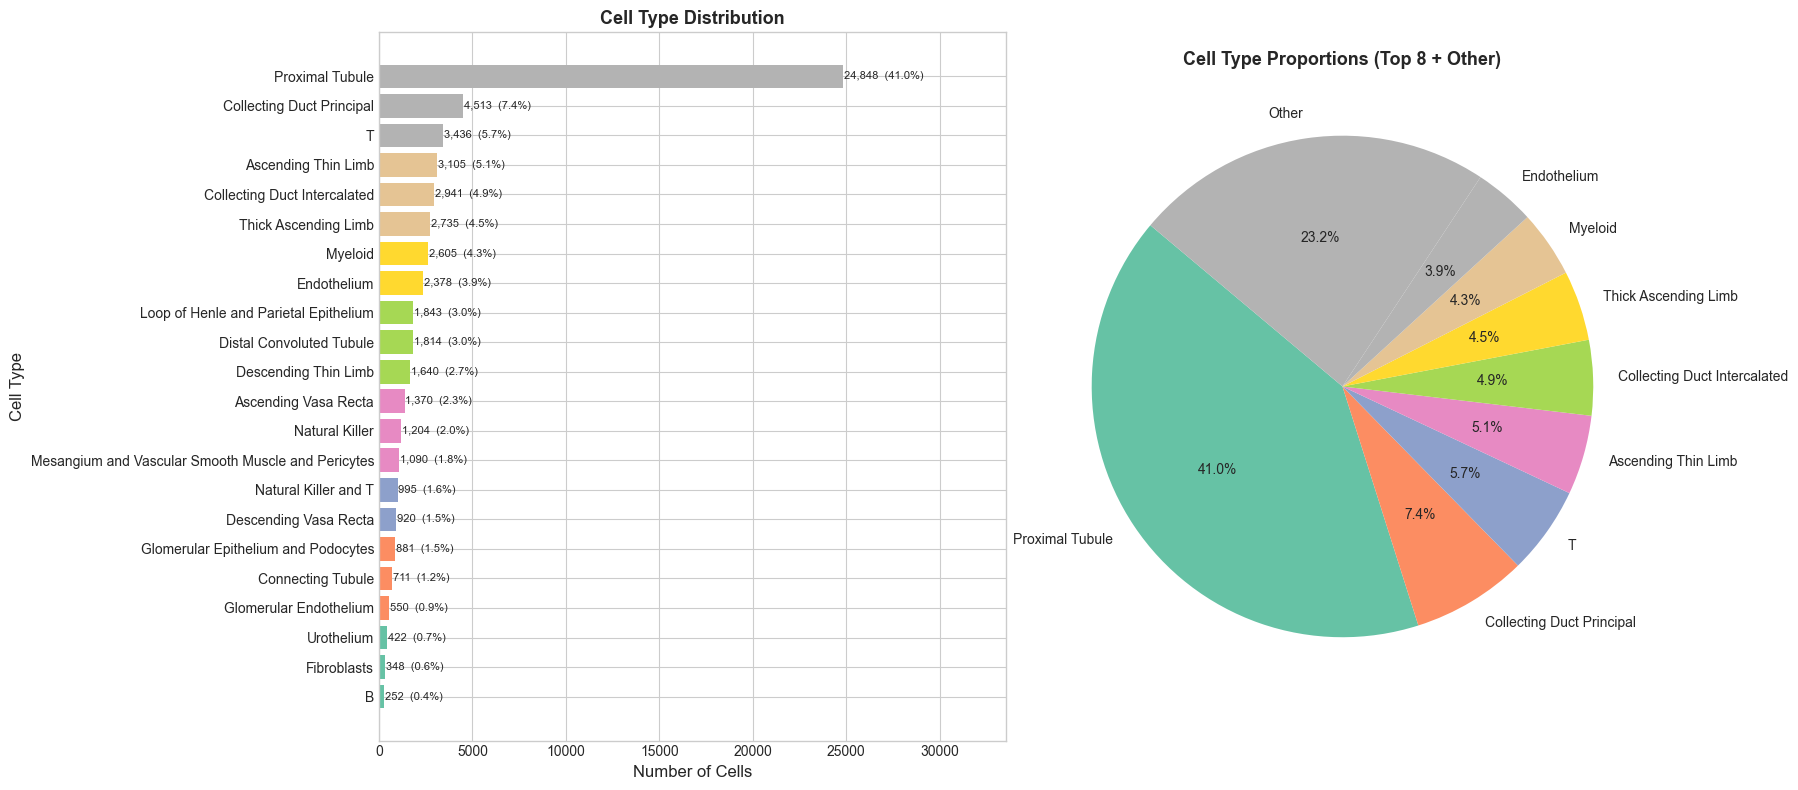

Total cells   : 60,601
Classes       : 22
Largest class : Proximal Tubule — 24,848 cells (41.0%)
Smallest class: B — 252 cells (0.4%)


In [8]:
label_counts = df[target_col].value_counts().sort_values(ascending=True)
total_cells  = len(df)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colours = plt.cm.Set2(np.linspace(0, 1, len(label_counts)))
bars = axes[0].barh(label_counts.index, label_counts.values, color=colours)
for bar, count in zip(bars, label_counts.values):
    axes[0].text(
        bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
        f'{count:,}  ({count/total_cells*100:.1f}%)',
        va='center', ha='left', fontsize=8
    )
axes[0].set_title('Cell Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Cells', fontsize=12)
axes[0].set_ylabel('Cell Type', fontsize=12)
axes[0].set_xlim(0, label_counts.max() * 1.35)

top_counts = label_counts.sort_values(ascending=False).head(8)
other_sum  = label_counts.sort_values(ascending=False).iloc[8:].sum()
pie_data   = pd.concat([top_counts, pd.Series({'Other': other_sum})])
axes[1].pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set2(np.linspace(0, 1, len(pie_data)))
)
axes[1].set_title('Cell Type Proportions (Top 8 + Other)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Total cells   : {total_cells:,}')
print(f'Classes       : {df[target_col].nunique()}')
print(f'Largest class : {label_counts.idxmax()} — {label_counts.max():,} cells ({label_counts.max()/total_cells*100:.1f}%)')
print(f'Smallest class: {label_counts.idxmin()} — {label_counts.min():,} cells ({label_counts.min()/total_cells*100:.1f}%)')

## 8. EDA — Missing Values

We calculate what percentage of each metadata column is empty, then plot only the columns that have at least some missing values. Red bars are columns that are more than 50% empty. Note that the 2,358 gene expression columns we will use for machine learning have zero missing values — undetected genes are stored as 0, not as empty.

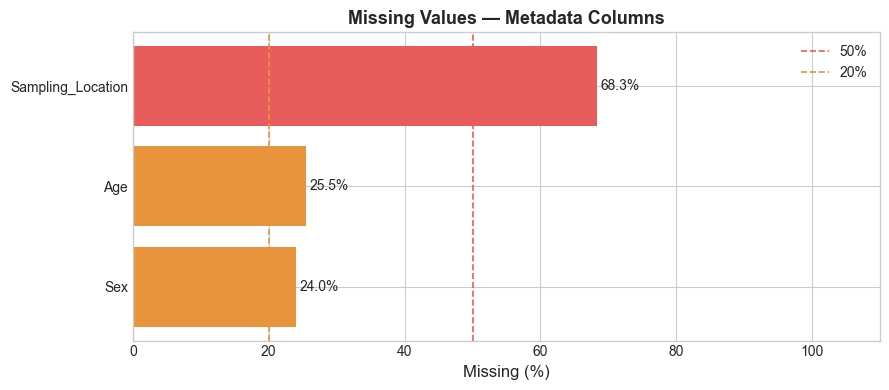

Missing values exist only in metadata columns.
The 2,358 gene expression columns used as ML features have no missing values.


In [9]:
missing_pct = (df[metadata_cols].isnull().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(9, 4))
colours = ['#E85C5C' if v > 50 else '#E8943C' if v > 20 else '#4C9BE8' for v in missing_pct.values]
ax.barh(missing_pct.index, missing_pct.values, color=colours)
ax.axvline(x=50, color='#E85C5C', linestyle='--', linewidth=1.2, label='50%')
ax.axvline(x=20, color='#E8943C', linestyle='--', linewidth=1.2, label='20%')
for i, (col, val) in enumerate(missing_pct.items()):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)
ax.set_title('Missing Values — Metadata Columns', fontsize=13, fontweight='bold')
ax.set_xlabel('Missing (%)', fontsize=12)
ax.set_xlim(0, 110)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Missing values exist only in metadata columns.')
print('The 2,358 gene expression columns used as ML features have no missing values.')

## 9. EDA — Prominent Classes

With 22 classes in the dataset, some cell types have far more representation than others. The top classes by count are the ones the model will have the most training data for.

We identify the top `top_n_classes` by count and visualise them. We also create a filtered dataset containing only these prominent classes — this is saved separately so you can choose in Notebook 2 whether to classify all 22 classes or focus on the most well-represented ones.

We sort all cell types by how many cells they have and take the top 10. We then print the ranked list with counts and percentages.

In [10]:
label_counts_desc = df[target_col].value_counts()
top_classes       = label_counts_desc.head(top_n_classes)
other_count       = label_counts_desc.iloc[top_n_classes:].sum()

print(f'Top {top_n_classes} cell types by count:')
print()
for rank, (label, count) in enumerate(top_classes.items(), start=1):
    print(f'  {rank:>2}. {label:<55}: {count:>6,}  ({count/total_cells*100:.1f}%)')
print()
print(f'Top {top_n_classes} classes combined : {top_classes.sum():,} cells ({top_classes.sum()/total_cells*100:.1f}%)')
print(f'Remaining {df[target_col].nunique() - top_n_classes} classes  : {other_count:,} cells ({other_count/total_cells*100:.1f}%)')

Top 10 cell types by count:

   1. Proximal Tubule                                        : 24,848  (41.0%)
   2. Collecting Duct Principal                              :  4,513  (7.4%)
   3. T                                                      :  3,436  (5.7%)
   4. Ascending Thin Limb                                    :  3,105  (5.1%)
   5. Collecting Duct Intercalated                           :  2,941  (4.9%)
   6. Thick Ascending Limb                                   :  2,735  (4.5%)
   7. Myeloid                                                :  2,605  (4.3%)
   8. Endothelium                                            :  2,378  (3.9%)
   9. Loop of Henle and Parietal Epithelium                  :  1,843  (3.0%)
  10. Distal Convoluted Tubule                               :  1,814  (3.0%)

Top 10 classes combined : 50,218 cells (82.9%)
Remaining 12 classes  : 10,383 cells (17.1%)


Two charts: a bar chart showing the top 10 most abundant cell types, and a pie chart comparing those top 10 collectively against all remaining cell types combined.

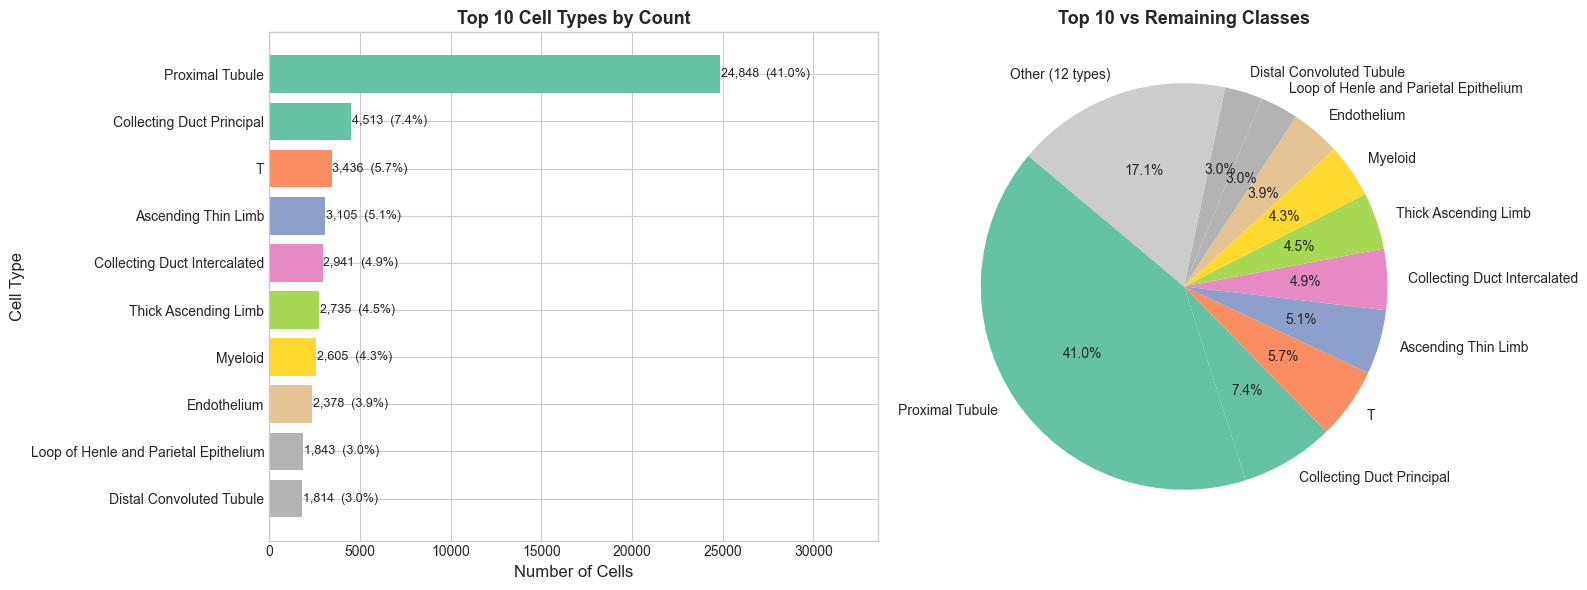

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colours_top = plt.cm.Set2(np.linspace(0, 1, top_n_classes))
bars_top = axes[0].barh(
    top_classes.index[::-1], top_classes.values[::-1], color=colours_top[::-1]
)
for bar, count in zip(bars_top, top_classes.values[::-1]):
    axes[0].text(
        bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
        f'{count:,}  ({count/total_cells*100:.1f}%)',
        va='center', ha='left', fontsize=9
    )
axes[0].set_title(f'Top {top_n_classes} Cell Types by Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Cells', fontsize=12)
axes[0].set_ylabel('Cell Type', fontsize=12)
axes[0].set_xlim(0, top_classes.max() * 1.35)

pie_labels  = list(top_classes.index) + [f'Other ({df[target_col].nunique() - top_n_classes} types)']
pie_values  = list(top_classes.values) + [other_count]
pie_colours = list(plt.cm.Set2(np.linspace(0, 1, top_n_classes))) + ['#cccccc']
axes[1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
            startangle=140, colors=pie_colours)
axes[1].set_title(f'Top {top_n_classes} vs Remaining Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

We create a filtered version of the dataset that contains only the top 10 cell types. This is saved alongside the full dataset so you can choose in Notebook 2 which one to work with.

In [12]:
df_top = df[df[target_col].isin(top_classes.index)].copy()

print(f'Full dataset ({df[target_col].nunique()} classes)            : {len(df):,} cells')
print(f'Top-{top_n_classes} subset ({top_n_classes} classes) : {len(df_top):,} cells')
print()
print('Classes in the top-N subset:')
for label, count in df_top[target_col].value_counts().items():
    print(f'  {label:<55}: {count:,}')

Full dataset (22 classes)            : 60,601 cells
Top-10 subset (10 classes) : 50,218 cells

Classes in the top-N subset:
  Proximal Tubule                                        : 24,848
  T                                                      : 3,436
  Ascending Thin Limb                                    : 3,105
  Thick Ascending Limb                                   : 2,735
  Myeloid                                                : 2,605
  Endothelium                                            : 2,378
  Loop of Henle and Parietal Epithelium                  : 1,843
  Distal Convoluted Tubule                               : 1,814


## 10. EDA — Genes Detected per Cell (`nFeature_RNA`)

`nFeature_RNA` records how many distinct genes were detected in each individual cell. In single-cell RNA sequencing, each cell is captured and sequenced separately, and only a fraction of its genes produce enough RNA to be measured. This metric is used as a quality check:

- A very low count can indicate a poor-quality cell or an empty droplet.
- A very high count may indicate two cells captured together (a doublet).

Two charts: a histogram showing how many genes were detected across all cells (with the median and mean marked), and a bar chart showing the median gene detection count broken down by cell type. The print statements below summarise the key statistics.

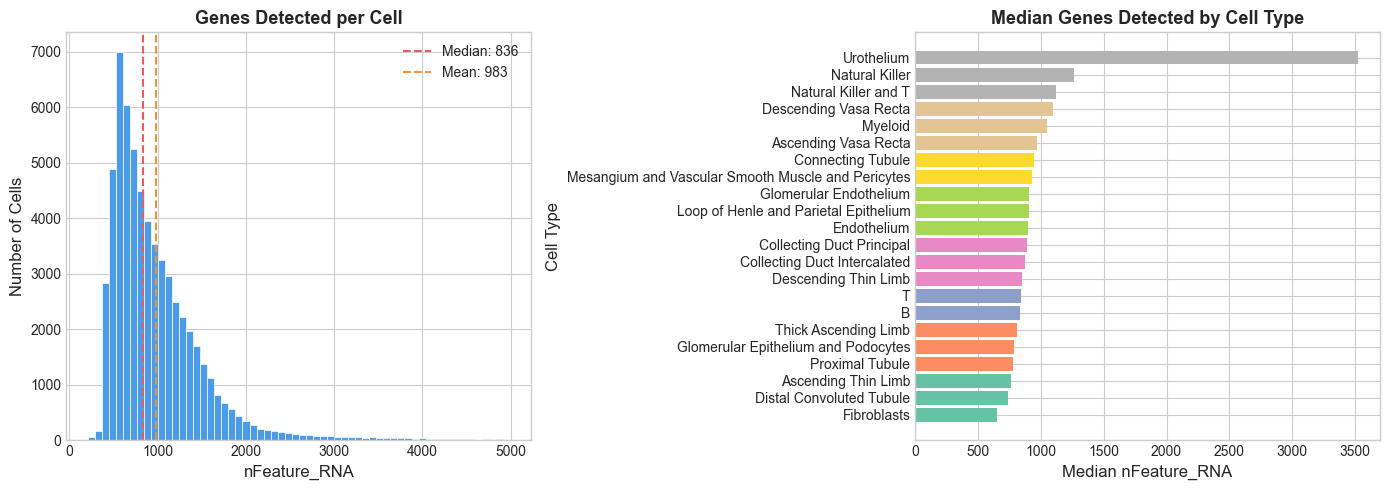

Min    : 205
Median : 836
Mean   : 983
Max    : 4,994

On average, each cell has 983 genes detected out of 2,358 total gene columns.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['nFeature_RNA'], bins=60, color='#4C9BE8', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['nFeature_RNA'].median(), color='#E85C5C', linestyle='--',
                linewidth=1.5, label=f'Median: {df["nFeature_RNA"].median():.0f}')
axes[0].axvline(df['nFeature_RNA'].mean(), color='#E8943C', linestyle='--',
                linewidth=1.5, label=f'Mean: {df["nFeature_RNA"].mean():.0f}')
axes[0].set_title('Genes Detected per Cell', fontsize=13, fontweight='bold')
axes[0].set_xlabel('nFeature_RNA', fontsize=12)
axes[0].set_ylabel('Number of Cells', fontsize=12)
axes[0].legend(fontsize=10)

median_per_type = df.groupby(target_col)['nFeature_RNA'].median().sort_values(ascending=True)
colours2 = plt.cm.Set2(np.linspace(0, 1, len(median_per_type)))
axes[1].barh(median_per_type.index, median_per_type.values, color=colours2)
axes[1].set_title('Median Genes Detected by Cell Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median nFeature_RNA', fontsize=12)
axes[1].set_ylabel('Cell Type', fontsize=12)

plt.tight_layout()
plt.show()

print(f'Min    : {df["nFeature_RNA"].min():,}')
print(f'Median : {df["nFeature_RNA"].median():,.0f}')
print(f'Mean   : {df["nFeature_RNA"].mean():,.0f}')
print(f'Max    : {df["nFeature_RNA"].max():,}')
print()
print(f'On average, each cell has {df["nFeature_RNA"].mean():.0f} genes detected out of {df.shape[1] - len(metadata_cols):,} total gene columns.')

**What do these graphs show?**

* **Left Graph (Histogram):** This shows how many distinct genes were detected per cell across the entire dataset. The distribution is right-skewed — most cells detect between **500 and 1,500 genes**, with a median of **836** and a mean of **983**. The long tail extending toward 4,994 represents high-quality cells that captured a broader range of transcripts. Very low counts (below ~200) would indicate poor-quality cells or empty droplets, but none were observed at that extreme here.
* **Right Graph (Bar Chart):** This breaks down the median gene-detection count by cell type. Different kidney cell types naturally have different levels of transcriptional activity — Proximal Tubule and Collecting Duct subtypes tend to detect more genes per cell than smaller immune populations. No cell type appears as an outlier severe enough to indicate a data quality issue.

## 11. EDA — Gene Expression Sparsity

Sparsity is the proportion of values in the gene expression matrix that are zero. In single-cell RNA sequencing this is expected — in any given cell most genes are either not expressed or expressed at levels too low to be captured. This is biological, not a data quality issue.

Genes that are zero in nearly every cell will have near-zero variance. The Variance Threshold step in Notebook 2 removes these genes efficiently, which is why understanding sparsity upfront is useful.

We identify all gene columns (everything that is not a metadata column), then for each cell count how many of its gene values are zero. From this we calculate the sparsity — the percentage of the entire gene expression matrix that is zero.

In [14]:
# Get all gene columns — everything that is not a metadata column
gene_cols = [c for c in df.columns if c not in metadata_cols]
print(f'Gene columns : {len(gene_cols):,}')
print('Computing sparsity...')

gene_df           = df[gene_cols]
zeros_per_cell    = (gene_df == 0).sum(axis=1)
sparsity_per_cell = zeros_per_cell / len(gene_cols) * 100
overall_sparsity  = zeros_per_cell.sum() / (gene_df.shape[0] * gene_df.shape[1]) * 100

print(f'Overall sparsity   : {overall_sparsity:.1f}%')
print(f'Avg zeros per cell : {zeros_per_cell.mean():.0f} out of {len(gene_cols):,} genes')
print(f'Avg detected/cell  : {len(gene_cols) - zeros_per_cell.mean():.0f} genes')

Gene columns : 2,358
Computing sparsity...


Overall sparsity   : 97.8%
Avg zeros per cell : 2306 out of 2,358 genes
Avg detected/cell  : 52 genes


Two charts: a histogram showing how sparse each individual cell is, and a bar chart showing the median sparsity broken down by cell type. The number printed below tells us what fraction of the entire gene expression matrix is zero.

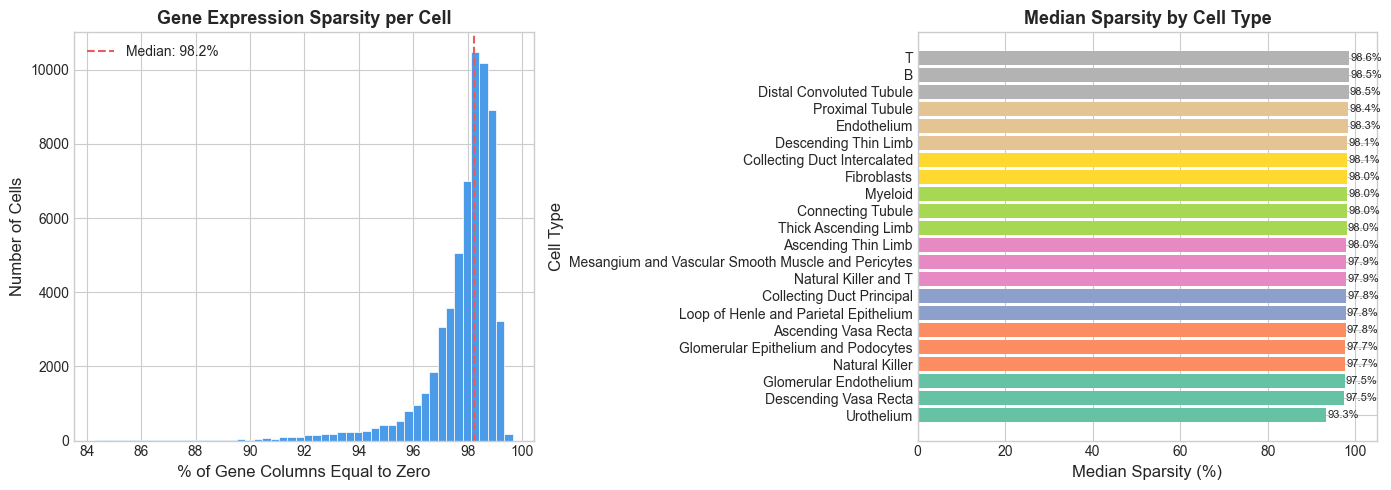

97.8% of all gene expression values are zero.
Genes that are near-zero across all cells will be removed by Variance Threshold in Notebook 2.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sparsity_per_cell, bins=50, color='#4C9BE8', edgecolor='white', linewidth=0.5)
axes[0].axvline(sparsity_per_cell.median(), color='#E85C5C', linestyle='--',
                linewidth=1.5, label=f'Median: {sparsity_per_cell.median():.1f}%')
axes[0].set_title('Gene Expression Sparsity per Cell', fontsize=13, fontweight='bold')
axes[0].set_xlabel('% of Gene Columns Equal to Zero', fontsize=12)
axes[0].set_ylabel('Number of Cells', fontsize=12)
axes[0].legend(fontsize=10)

df_temp = df[[target_col]].copy()
df_temp['sparsity_pct'] = sparsity_per_cell.values
median_sparsity = df_temp.groupby(target_col)['sparsity_pct'].median().sort_values(ascending=True)
colours3 = plt.cm.Set2(np.linspace(0, 1, len(median_sparsity)))
axes[1].barh(median_sparsity.index, median_sparsity.values, color=colours3)
for i, (ct, val) in enumerate(median_sparsity.items()):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)
axes[1].set_title('Median Sparsity by Cell Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Sparsity (%)', fontsize=12)
axes[1].set_ylabel('Cell Type', fontsize=12)
axes[1].set_xlim(0, 105)

plt.tight_layout()
plt.show()

print(f'{overall_sparsity:.1f}% of all gene expression values are zero.')
print('Genes that are near-zero across all cells will be removed by Variance Threshold in Notebook 2.')

**What is Sparsity and what do these graphs show?**

* **What is Sparsity?** Sparsity refers to the fraction of gene measurements that are exactly zero. In single-cell RNA sequencing, each cell only activates a small subset of its total genes at any given moment, and RNA capture is incomplete even for expressed genes. This dataset has an **overall sparsity of 97.8%** — on average, each cell has only **52 of 2,358 genes** with a non-zero value. This is entirely normal and expected for scRNA-seq data.
* **Left Graph (Histogram):** This shows how sparse each individual cell is. Almost all cells have between 95% and 99% of their gene values set to zero. The tight clustering of the distribution confirms that sparsity is uniform across the dataset rather than driven by a subset of low-quality cells.
* **Right Graph (Bar Chart):** This shows median sparsity broken down by cell type. All 10 cell types cluster very tightly around the 97–98% range, confirming that high sparsity is a consistent biological property of kidney cells in this dataset — not an artifact of any particular study or cell type. This high sparsity is the reason Variance Threshold in Notebook 2 removes very few additional genes after the zero-variance step: most genes have *some* non-zero expression in at least a few cells.

## 12. Save Cleaned Datasets

We save two CSV files to `data_dir`. `kidney_cells_clean.csv` contains all 22 cell types; `kidney_cells_top_classes.csv` contains only the 10 most abundant classes. Notebook 2 reads one of these as its input.

In [16]:
# Save both versions: the full 22-class dataset and the top-10 focused subset
top_clean_file = data_dir / 'kidney_cells_top_classes.csv'

df.to_csv(clean_file, index=False)
df_top.to_csv(top_clean_file, index=False)

print(f'kidney_cells_clean.csv       : {len(df):,} cells, {df[target_col].nunique()} classes')
print(f'kidney_cells_top_classes.csv : {len(df_top):,} cells, {df_top[target_col].nunique()} classes')

kidney_cells_clean.csv       : 60,601 cells, 22 classes
kidney_cells_top_classes.csv : 50,218 cells, 10 classes


## 13. Summary

A final printout summarising everything we did in this notebook — how many cells and classes remain, the gene count, the sparsity, and the full class distribution.

In [17]:
print('NOTEBOOK 1 — DATASET SUMMARY')
print()
print(f'Raw rows                  : {len(df) + sum(class_counts[rare_classes]):,}')
print(f'Rare classes dropped      : {len(rare_classes)}  {rare_classes}')
print(f'Cells removed             : {sum(class_counts[rare_classes])}')
print(f'Final cells               : {len(df):,}')
print(f'Final classes             : {df[target_col].nunique()}')
print(f'Gene expression features  : {len(gene_cols):,}')
print(f'Overall sparsity          : {overall_sparsity:.1f}%')
print()
print('Final class distribution:')
for label, count in df[target_col].value_counts().items():
    print(f'  {label:<55}: {count:>6,}  ({count/len(df)*100:.1f}%)')
print()
print('Files saved:')
print(f'  kidney_cells_clean.csv       (all {df[target_col].nunique()} classes)')
print(f'  kidney_cells_top_classes.csv (top {top_n_classes} classes only)')
print()
print('In Notebook 2, set input_file to either file depending on')
print(f'whether you want to classify all {df[target_col].nunique()} classes or the top {top_n_classes}.')
print()
print()
print('Next: run 02_preprocessing.ipynb')

NOTEBOOK 1 — DATASET SUMMARY

Raw rows                  : 60,725
Rare classes dropped      : 3  ['Neutrophil', 'Mast', 'Plasmacytoid']
Cells removed             : 124
Final cells               : 60,601
Final classes             : 22
Gene expression features  : 2,358
Overall sparsity          : 97.8%

Final class distribution:
  Proximal Tubule                                        : 24,848  (41.0%)
  T                                                      :  3,436  (5.7%)
  Ascending Thin Limb                                    :  3,105  (5.1%)
  Thick Ascending Limb                                   :  2,735  (4.5%)
  Myeloid                                                :  2,605  (4.3%)
  Endothelium                                            :  2,378  (3.9%)
  Loop of Henle and Parietal Epithelium                  :  1,843  (3.0%)
  Distal Convoluted Tubule                               :  1,814  (3.0%)
  Descending Thin Limb                                   :  1,640  (2.7%)
  Asc